In [2]:
from skimage import io, color, morphology
from skimage.util import img_as_float, img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.filters import threshold_otsu
from skimage import segmentation
from skimage import measure
from skimage.color import label2rgb

In [11]:
def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis('off')
    plt.show()

/tmp/ipykernel_55517/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


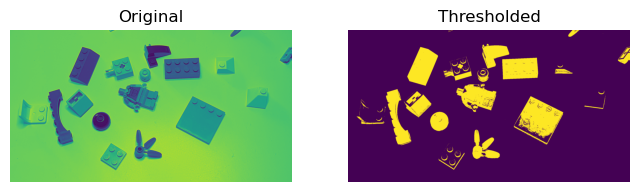

In [12]:
lego_img = io.imread("../data/lego_4_small.png", as_gray=True)
T = threshold_otsu(lego_img)
lego_bin = lego_img < T
show_comparison(lego_img, lego_bin, "Thresholded")

/tmp/ipykernel_55517/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


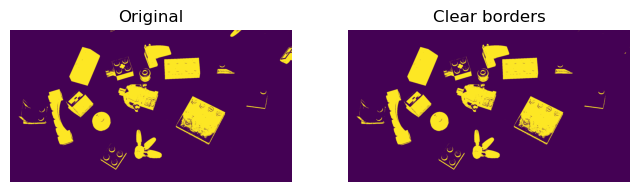

True


In [14]:
lego_cleaned = segmentation.clear_border(lego_bin)
show_comparison(lego_bin, lego_cleaned, "Clear borders")
print(lego_cleaned.max())

/tmp/ipykernel_55517/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


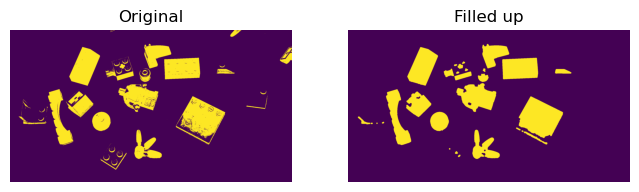

In [15]:
from skimage.morphology import opening, closing, disk
lego_filled = opening(closing(lego_cleaned, disk(5)), disk(5))
show_comparison(lego_bin, lego_filled, "Filled up")

Number of labels: 29


/tmp/ipykernel_55517/578429982.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


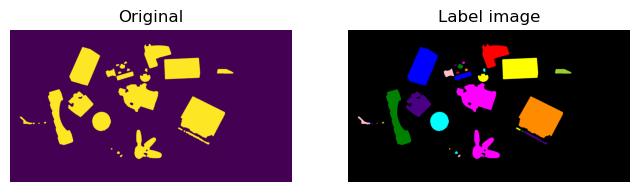

In [19]:
import skimage.color
label_img = measure.label(lego_filled)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")
show_comparison(lego_filled, skimage.color.label2rgb(label_img), "Label image")

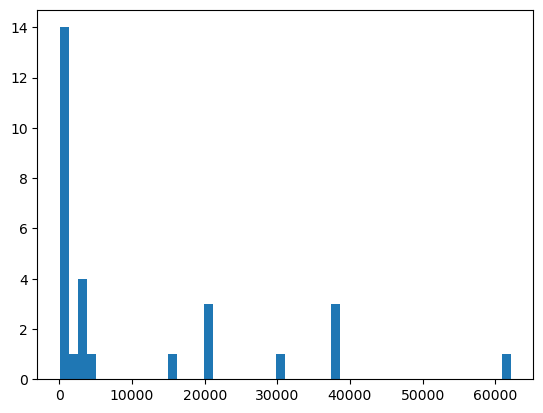

In [20]:
region_props = measure.regionprops(label_img)
areas = np.array([prop.area for prop in region_props])
plt.hist(areas, bins=50)
plt.show()

/tmp/ipykernel_68146/133392236.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gray, vmin=10, vmax=150)
/tmp/ipykernel_68146/133392236.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


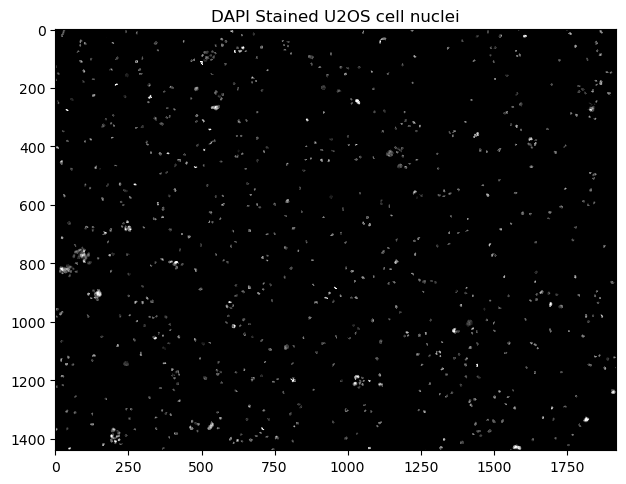

In [61]:
in_dir = "../data/"
# img_org = io.imread(in_dir + 'Sample E2 - U2OS DAPI channel.tiff')
img_org = io.imread("../data/Sample G1 - COS7 cells DAPI channel.tiff")

# slice to extract smaller image
img_small = img_org
img_gray = img_as_ubyte(img_small) 
io.imshow(img_gray, vmin=10, vmax=150)
plt.title('DAPI Stained U2OS cell nuclei')
io.show()

/tmp/ipykernel_68146/158489352.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


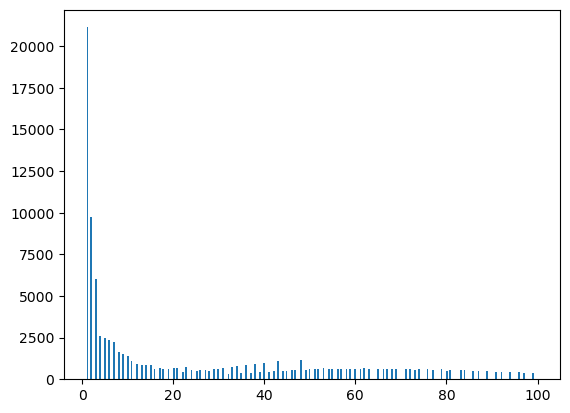

In [41]:
# avoid bin with value 0 due to the very large number of background pixels
plt.hist(img_gray.ravel(), bins=256, range=(1, 100))
io.show()

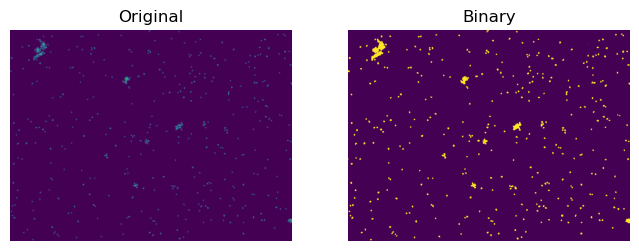

In [42]:
T = 10
bin_nuclei = img_gray > T
show_comparison(img_gray, bin_nuclei, "Binary")

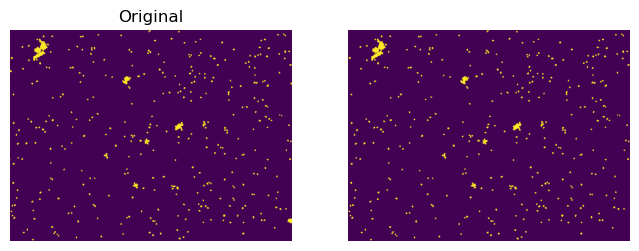

In [43]:
clear_nuclei = segmentation.clear_border(bin_nuclei)
show_comparison(bin_nuclei, clear_nuclei,"")

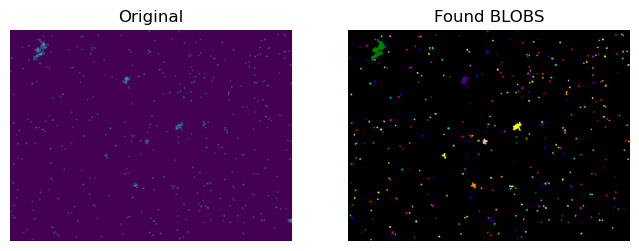

In [44]:
label_img = measure.label(clear_nuclei)
image_label_overlay = label2rgb(label_img)
show_comparison(img_gray, image_label_overlay, 'Found BLOBS')

In [45]:
region_props = measure.regionprops(label_img)
areas = np.array([prop.area for prop in region_props])

/tmp/ipykernel_68146/1561716930.py:2: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


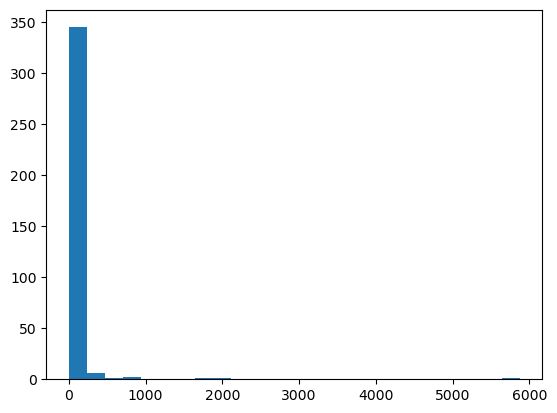

1.0 5874.0
[1.710e+02 9.700e+01 7.400e+01 1.000e+02 9.200e+01 1.040e+02 9.200e+01
 1.280e+02 1.090e+02 1.060e+02 1.070e+02 1.300e+02 1.210e+02 8.800e+01
 5.874e+03 7.600e+01 9.200e+01 1.210e+02 9.300e+01 1.420e+02 1.050e+02
 1.300e+02 6.000e+00 1.200e+02 1.120e+02 1.190e+02 1.240e+02 1.380e+02
 9.500e+01 1.510e+02 1.280e+02 1.010e+02 1.150e+02 9.100e+01 1.010e+02
 2.710e+02 1.630e+02 1.000e+02 9.500e+01 1.140e+02 1.140e+02 1.030e+02
 1.300e+02 1.040e+02 1.090e+02 7.900e+01 8.700e+01 8.500e+01 8.700e+01
 8.500e+01 1.030e+02 1.250e+02 1.530e+02 1.330e+02 8.900e+01 1.510e+02
 1.730e+02 1.050e+02 1.000e+02 1.100e+02 1.220e+02 1.140e+02 1.130e+02
 9.700e+01 9.000e+01 1.550e+02 1.080e+02 1.430e+02 1.460e+02 9.300e+01
 1.260e+02 9.600e+01 9.000e+01 1.390e+02 1.000e+02 1.050e+02 1.090e+02
 1.120e+02 1.500e+02 8.900e+01 1.340e+02 1.040e+02 1.170e+02 1.490e+02
 8.200e+01 1.360e+02 8.500e+01 7.600e+01 8.300e+01 9.900e+01 8.700e+01
 1.760e+02 1.020e+02 8.700e+01 9.600e+01 1.715e+03 1.170e+02 1.200

In [46]:
plt.hist(areas, bins=25)
io.show()
print(areas.min(), areas.max())
print(areas)

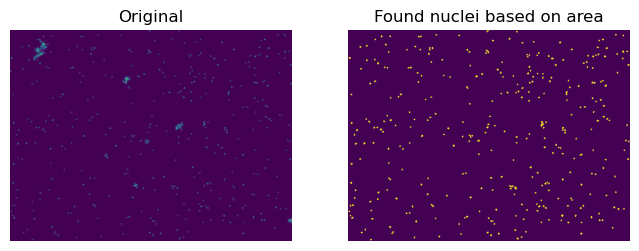

Removed: 30


In [52]:
min_area = 80
max_area = 400

# Create a copy of the label_img
label_img_filter = label_img
for region in region_props:
	# Find the areas that do not fit our criteria
	if region.area > max_area or region.area < min_area:
		remove_count += 1
		# set the pixels in the invalid areas to background
		for cords in region.coords:
			label_img_filter[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area = label_img_filter > 0
show_comparison(img_gray, i_area, 'Found nuclei based on area')
print(f"Removed: {remove_count}")

In [53]:
perimeters = np.array([prop.perimeter for prop in region_props])

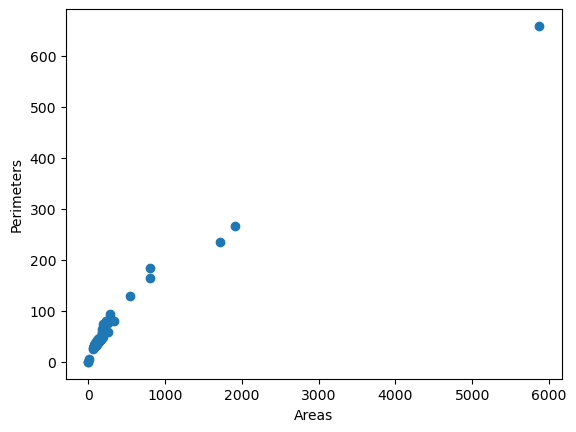

In [54]:
plt.scatter(areas, perimeters)
plt.xlabel("Areas")
plt.ylabel("Perimeters")
plt.show()

In [55]:
circularity = 4*np.pi *areas / (perimeters * perimeters)
print(circularity)

[0.6509349  1.03097751 1.02351343 1.01344175 0.8091654  0.9871969
 0.94534961 0.9469937  1.03465829 1.00618146 0.98374269 0.8748232
 0.94835672 0.98207154 0.16993515 1.05117595 1.02671116 0.90583975
 1.00256248 0.98201964 0.92350399 0.84882235 3.01592895 0.92460395
 0.83846324 0.9846536  0.90231209 0.96531523 1.02412296 0.95275955
 1.02798654 1.05238256 0.98082082 0.98100199 0.94088928 0.49419162
 1.00199813 0.85288767 0.98986478 0.81050484 1.04809969 1.02379443
 0.94597235 1.01976865 0.92964756 1.05140629 0.97091164 0.94859183
 0.92469117 0.98259844 1.02379443 0.97970735 1.00224317 0.9956751
 1.06639492 0.98914195 0.95152133 0.93547552 0.93669301 0.96748037
 0.85339463 1.00266147 1.03890583 1.04568344 1.00439135 0.98872039
 0.96220339 1.01668589 0.94157743 1.03787106 0.99962316 0.98645177
 1.00439135 0.99975386 0.99397518 0.99668918 1.00213041 1.02971198
 0.88920057 0.99323145 0.93733508 0.9871969  0.95616112 0.99151606
 1.0347852  0.97817644 1.03390189 1.05117595 1.00957479 1.0033073

/tmp/ipykernel_68146/2618470535.py:1: RuntimeWarning: divide by zero encountered in divide
  circularity = 4*np.pi *areas / (perimeters * perimeters)


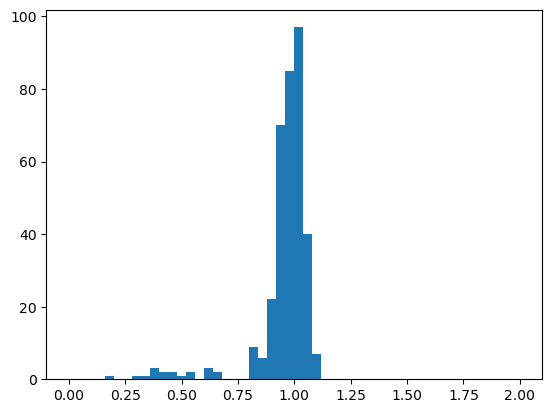

In [58]:
plt.hist(circularity, bins=50, range=(0,2))
plt.show()

/tmp/ipykernel_68146/196681227.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  if (region.area * 4 * np.pi / (region.perimeter * region.perimeter)) < 0.7:


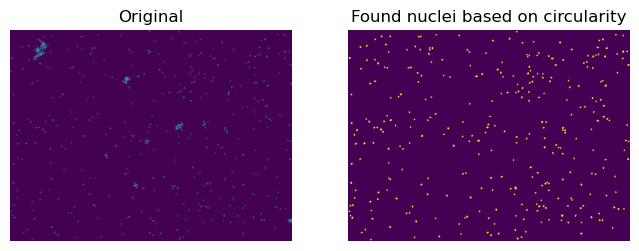

18


In [59]:
acceptance_ration = 0.7
# Create a copy of the label_img
remove_count = 0
label_img_filter = label_img
for region in region_props:
	# Find the areas that do not fit our criteria
	if (region.area * 4 * np.pi / (region.perimeter * region.perimeter)) < 0.7:
		remove_count += 1
		# set the pixels in the invalid areas to background
		for cords in region.coords:
			label_img_filter[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area = label_img_filter > 0
show_comparison(img_gray, i_area, 'Found nuclei based on circularity')
print(remove_count)

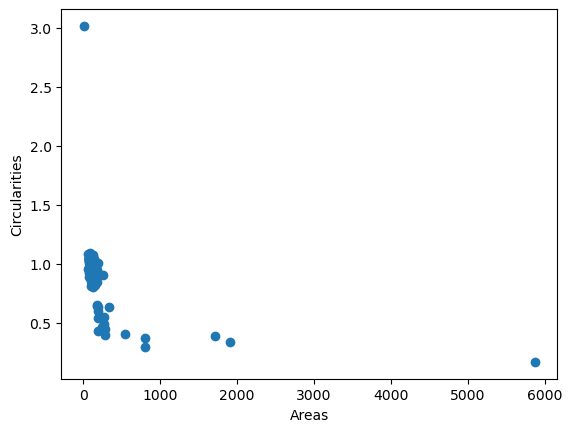

In [60]:
plt.scatter(areas, circularity)
plt.xlabel("Areas")
plt.ylabel("Circularities")
plt.show()